<a href="https://colab.research.google.com/github/NikhilGeorge01/DeepLearningPractice/blob/main/MLPTweaking(Week3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import files
files.upload()

Saving kaggle (2).json to kaggle (2).json


{'kaggle (2).json': b'{"username":"nikhilgeorge2705","key":"76bb77c1a0015d11cd25f1e34a8ae5e3"}'}

In [6]:
!pip install kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle (2).json

/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `chmod 600 ~/.kaggle/kaggle (2).json'


In [8]:
!kaggle datasets download -d andrewmvd/covid19-ct-scans
!unzip covid19-ct-scans.zip

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/covid19-ct-scans
License(s): other
 99% 1.02G/1.03G [00:09<00:00, 122MB/s]
100% 1.03G/1.03G [00:09<00:00, 121MB/s]
Archive:  covid19-ct-scans.zip
  inflating: ct_scans/coronacases_org_001.nii  
  inflating: ct_scans/coronacases_org_002.nii  
  inflating: ct_scans/coronacases_org_003.nii  
  inflating: ct_scans/coronacases_org_004.nii  
  inflating: ct_scans/coronacases_org_005.nii  
  inflating: ct_scans/coronacases_org_006.nii  
  inflating: ct_scans/coronacases_org_007.nii  
  inflating: ct_scans/coronacases_org_008.nii  
  inflating: ct_scans/coronacases_org_009.nii  
  inflating: ct_scans/coronacases_org_010.nii  
  inflating: ct_scans/radiopaedia_org_covid-19-pneumonia-10_85902_1-dcm.nii  
  inflating: ct_scans/radiopaedia_org_covid-19-pneumonia-10_85902_3-dcm.nii  
  inflating: ct_scans/radiopaedia_org_covid-19-pneumonia-14_85914_0-dcm.nii  
  inflating: ct_scans/radiopaedia_org_covid-19-pneumonia-27_86410_0-dcm.nii  
  infla

Learning Rate: 0.0001 | Final Loss: 0.6688
Learning Rate: 0.001 | Final Loss: 0.6197
Learning Rate: 0.01 | Final Loss: 0.4966
Learning Rate: 0.1 | Final Loss: 0.0028
Learning Rate: 0.5 | Final Loss: 0.3466


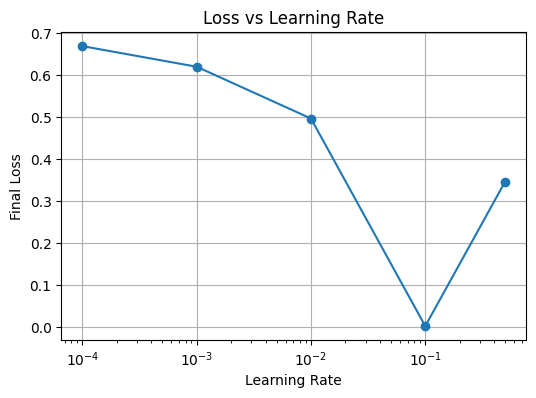

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Fix seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# XOR Dataset
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

y = np.array([0,1,1,0])

# Function to build MLP with variable learning rate
def build_model(lr):
    model = keras.Sequential([
        keras.Input(shape=(2,)),
        layers.Dense(8, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    optimizer = keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer,
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Learning rates to test
learning_rates = [0.0001, 0.001, 0.01, 0.1, 0.5]
final_losses = []

# Train model for each learning rate
for lr in learning_rates:
    model = build_model(lr)
    history = model.fit(X, y, epochs=100, verbose=0)
    final_losses.append(history.history['loss'][-1])
    print(f"Learning Rate: {lr} | Final Loss: {final_losses[-1]:.4f}")

# Plot Loss vs Learning Rate
plt.figure(figsize=(6,4))
plt.plot(learning_rates, final_losses, marker='o')
plt.xscale('log')
plt.xlabel("Learning Rate")
plt.ylabel("Final Loss")
plt.title("Loss vs Learning Rate")
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Final Predictions:
[[0]
 [0]
 [1]
 [1]]


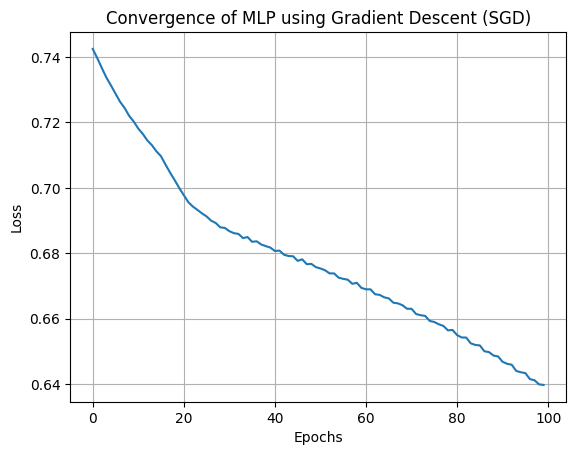

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Fix seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# XOR dataset
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

y = np.array([0,1,1,0])

# Build MLP model
model = keras.Sequential([
    keras.Input(shape=(2,)),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Use pure Gradient Descent (SGD)
optimizer = keras.optimizers.SGD(learning_rate=0.1)

model.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train model
history = model.fit(X, y, epochs=100, verbose=0)

# Predictions
pred = (model.predict(X) > 0.5).astype(int)
print("Final Predictions:")
print(pred)

# Plot convergence (Loss vs Epoch)
plt.plot(history.history['loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Convergence of MLP using Gradient Descent (SGD)")
plt.grid(True)
plt.show()

Learning Rate: 0.0001 | Accuracy: 1.0000
Learning Rate: 0.001 | Accuracy: 1.0000
Learning Rate: 0.01 | Accuracy: 1.0000
Learning Rate: 0.1 | Accuracy: 1.0000
Learning Rate: 1 | Accuracy: 1.0000


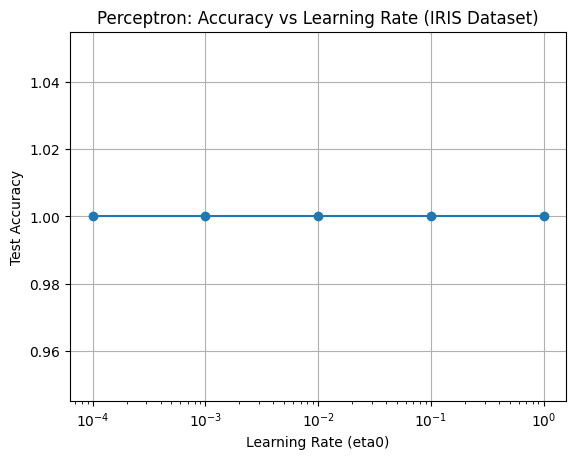


Final Classification Report (last model):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        15

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# For clearer Perceptron behavior, use binary classification (Setosa vs others)
X = X[y != 2]
y = y[y != 2]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Feature scaling is important for Perceptron
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Learning rates to test
learning_rates = [0.0001, 0.001, 0.01, 0.1, 1]
accuracies = []

for lr in learning_rates:
    model = Perceptron(
        eta0=lr,
        max_iter=1000,
        tol=1e-3,
        random_state=42,
        shuffle=True
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"Learning Rate: {lr} | Accuracy: {acc:.4f}")

# Plot Accuracy vs Learning Rate
plt.plot(learning_rates, accuracies, marker='o')
plt.xscale('log')
plt.xlabel("Learning Rate (eta0)")
plt.ylabel("Test Accuracy")
plt.title("Perceptron: Accuracy vs Learning Rate (IRIS Dataset)")
plt.grid(True)
plt.show()

print("\nFinal Classification Report (last model):")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Learning Rate: 0.0001 -> Accuracy: 1.0000
Learning Rate: 0.001 -> Accuracy: 1.0000
Learning Rate: 0.01 -> Accuracy: 1.0000
Learning Rate: 0.1 -> Accuracy: 1.0000


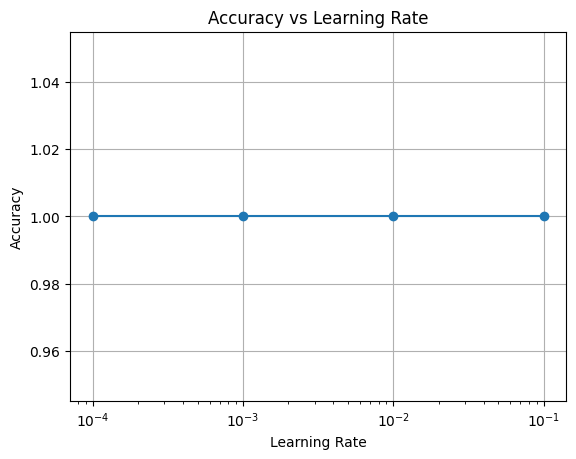

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iterations: 100 -> Accuracy: 1.0000
Iterations: 300 -> Accuracy: 1.0000
Iterations: 500 -> Accuracy: 1.0000
Iterations: 1000 -> Accuracy: 1.0000


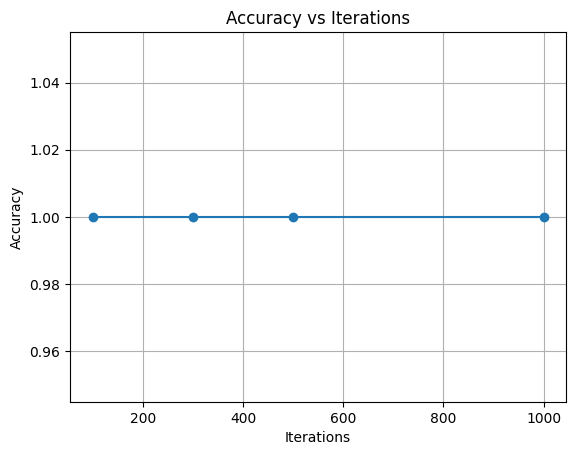

In [17]:
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
metadata = pd.read_csv("metadata.csv")

X_features = []
y_labels = []
for idx, row in metadata.iterrows():
    ct_path = row['ct_scan'].replace("../input/covid19-ct-scans/", "")
    infection_path = row['infection_mask'].replace("../input/covid19-ct-scans/", "")
    ct = nib.load(ct_path).get_fdata()
    infection_mask = nib.load(infection_path).get_fdata()
    mean_val = np.mean(ct)
    std_val = np.std(ct)
    max_val = np.max(ct)
    X_features.append([mean_val, std_val, max_val])
    y_labels.append(1 if np.sum(infection_mask) > 0 else 0)
X = np.array(X_features)
y = np.array(y_labels)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
learning_rates = [0.0001, 0.001, 0.01, 0.1]
lr_results = []
for lr in learning_rates:
    model = MLPClassifier(
        hidden_layer_sizes=(8,),
        learning_rate_init=lr,
        max_iter=100,
        random_state=42
    )
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    lr_results.append(acc)
    print(f"Learning Rate: {lr} -> Accuracy: {acc:.4f}")

plt.figure()
plt.plot(learning_rates, lr_results, marker='o')
plt.xscale('log')
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Learning Rate")
plt.grid(True)
plt.show()
iterations = [100, 300, 500, 1000]
iter_results = []

for it in iterations:
    model = MLPClassifier(
        hidden_layer_sizes=(8,),
        learning_rate_init=0.01,
        max_iter=it,
        random_state=42
    )
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    iter_results.append(acc)
    print(f"Iterations: {it} -> Accuracy: {acc:.4f}")

plt.figure()
plt.plot(iterations, iter_results, marker='o')
plt.xlabel("Iterations")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Iterations")
plt.grid(True)
plt.show()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.8359 - loss: 0.5579 - val_accuracy: 0.9658 - val_loss: 0.1107
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9641 - loss: 0.1226 - val_accuracy: 0.9710 - val_loss: 0.0910
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9779 - loss: 0.0752 - val_accuracy: 0.9757 - val_loss: 0.0824
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9839 - loss: 0.0526 - val_accuracy: 0.9732 - val_loss: 0.0869
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9881 - loss: 0.0390 - val_accuracy: 0.9723 - val_loss: 0.0938
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9912 - loss: 0.0294 - val_accuracy: 0.9693 - val_loss: 0.1099
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9921 - loss: 0.0257 - val_accuracy: 0.9778 - val_loss: 0.0878
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/st

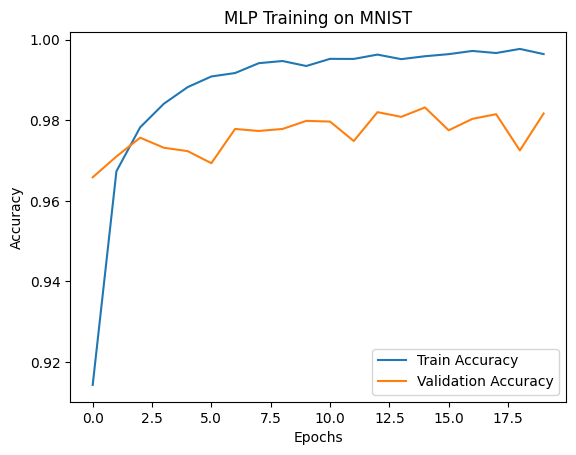

In [18]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

# Fix seed
tf.random.set_seed(42)

# ----------------------------
# 1️⃣ Load MNIST Dataset
# ----------------------------
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Normalize pixel values (0–255 → 0–1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# Flatten 28x28 → 784
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

# ----------------------------
# 2️⃣ Build MLP Model
# ----------------------------
model = keras.Sequential([
    keras.Input(shape=(784,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ----------------------------
# 3️⃣ Train Model
# ----------------------------
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=128,
    verbose=1
)

# ----------------------------
# 4️⃣ Evaluate
# ----------------------------
test_loss, test_acc = model.evaluate(X_test, y_test)
print("\nTest Accuracy:", test_acc)

# ----------------------------
# 5️⃣ Plot Training Curve
# ----------------------------
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("MLP Training on MNIST")
plt.show()